# Simple Actor-Critic (Defender) vs. DQN (Attacker) for the Budgeted Attack-Defense Game

In [31]:
# Importing necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [32]:
# Necessary imports for the attack-defense problem
# Assuming 'utils.py' exists in the same directory
from utils import prob_success, attacker_lingo_model 

# Parameters
n_targets = 5 # Number of targets
alpha, beta, A = 1, 1, 0.1
attacker_budget = 5 # Attacker's investment (Million USD)
defender_budget = 30 # Defender's Investment (Million USD)

# Infrastructure valuations for n targets
B = np.array([50, 20, 35, 45, 30]) # Attacker's valuations 
D = np.array([50, 150, 100, 80, 120]) # Defender's valuations

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
# Simple 2-layer neural network for Actor
class Actor(nn.Module):
    def __init__(self, n_targets, hidden_size=64):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(n_targets, hidden_size)
        self.fc2 = nn.Linear(hidden_size, n_targets)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        # Softmax to get allocation probabilities
        return F.softmax(x, dim=-1)

# Simple 2-layer neural network for Critic
class Critic(nn.Module):
    def __init__(self, n_targets, hidden_size=64):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(n_targets, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        value = self.fc2(x)
        return value

In [34]:
# Agent class combining Actor and Critic (for Defender)
class ActorCriticAgent:
    def __init__(self, n_targets, budget, lr_actor=1e-3, lr_critic=1e-3):
        self.n_targets = n_targets
        self.budget = budget
        
        self.actor = Actor(n_targets)
        self.critic = Critic(n_targets)
        
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
    
    def get_allocation(self, state):
        """Get budget allocation across targets"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        probs = self.actor(state_tensor)
        
        # Sample from the distribution
        dist = torch.distributions.Categorical(probs)
        # Sample 'budget' number of times
        actions = dist.sample((self.budget,))
        
        # Convert to allocation vector
        allocation = torch.zeros(self.n_targets)
        for a in actions:
            allocation[a] += 1
        
        log_probs = dist.log_prob(actions).sum()
        
        return allocation, log_probs
    
    def update(self, state, log_prob, reward, next_state, gamma=0.99):
        """Update actor and critic networks"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)
        
        # Critic update
        current_value = self.critic(state_tensor)
        next_value = self.critic(next_state_tensor)
        td_target = reward + gamma * next_value
        td_error = td_target - current_value
        
        critic_loss = td_error.pow(2).mean()
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        # Actor update
        advantage = td_error.detach()
        actor_loss = -(log_prob * advantage)
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

In [35]:
# Greedy Attacker Agent (Fixed Policy)

class GreedyAttackerAgent:
    def __init__(self, n_targets, budget, valuations):
        self.n_targets = n_targets
        self.budget = budget
        
        # Find the target with the maximum valuation
        target_to_attack = np.argmax(valuations)
        
        # Create the fixed allocation tensor
        self.allocation = torch.zeros(n_targets, device=device)
        self.allocation[target_to_attack] = budget
        
        print(f"Greedy Attacker initialized.")
        print(f"  Target valuations (B): {valuations}")
        print(f"  Attacking target {target_to_attack} with max valuation {valuations[target_to_attack]}")
        print(f"  Fixed allocation: {self.allocation.cpu().numpy()}")

    def get_allocation(self, state):
        """Returns the fixed greedy allocation"""
        # The 'log_prob' (or action index for DQN) is not needed
        # We return 'None' for that placeholder
        return self.allocation, None

    # This agent does not learn
    def update(self, *args, **kwargs):
        pass
    
    def learn(self, *args, **kwargs):
        pass

In [36]:
class AttackDefenseGame:
    def __init__(self, n_targets, attacker_budget, defender_budget):
        self.n_targets = n_targets
        self.attacker_budget = attacker_budget
        self.defender_budget = defender_budget
        
        # Initialize state (could be target values, vulnerabilities, etc.)
        self.state = np.ones(n_targets)
    
    def get_rewards(self, attacker_allocation, defender_allocation):
        """
        Compute rewards based on allocations using contest success function.
        Leave blank for user to implement.
        
        Args:
            attacker_allocation: torch.Tensor of shape (n_targets,)
            defender_allocation: torch.Tensor of shape (n_targets,)
        
        Returns:
            attacker_reward: float
            defender_reward: float
        """
        prob_successes = [prob_success(Ti=Ti,Gi=Gi, alpha=alpha, beta=beta, Ai=A) 
                         for Ti,Gi in zip(attacker_allocation,defender_allocation)]
        
        attacker_reward = np.dot(B, prob_successes)
        defender_reward = -1 * np.dot(D, prob_successes)
        
        return attacker_reward, defender_reward
    
    def step(self, attacker_allocation, defender_allocation):
        """Execute one step of the game"""
        attacker_reward, defender_reward = self.get_rewards(
            attacker_allocation, defender_allocation
        )
        
        # State can be updated based on game dynamics
        next_state = self.state.copy()
        
        return next_state, attacker_reward, defender_reward

## With Attacker (DQN) and Defender (Actor-Critic)

In [37]:
# Training
n_episodes=10000

game = AttackDefenseGame(n_targets, attacker_budget, defender_budget)
# Initialize the new GreedyAttackerAgent, passing the valuations B
attacker = GreedyAttackerAgent(n_targets, attacker_budget, B)
defender = ActorCriticAgent(n_targets, defender_budget, lr_actor=1e-3, lr_critic=1e-3)

# To record for plots
attacker_gains = []
defender_losses = []
defender_allocations = []


for episode in range(n_episodes):
    state = game.state
    
    # Get allocations from both agents
    # Attacker (Greedy) just returns its fixed policy
    attacker_allocation, _ = attacker.get_allocation(state)
    # Defender (AC) samples from its policy
    defender_allocation, defender_log_prob = defender.get_allocation(state)
    
    # Execute game step
    # We pass .cpu() as the game step expects numpy or cpu tensors
    next_state, attacker_reward, defender_reward = game.step(
        attacker_allocation.cpu(), defender_allocation.cpu()
    )
    
    # The attacker does not learn
    # attacker.learn() - REMOVED
    
    # Update Defender (Actor-Critic)
    # The defender learns to respond to the attacker's reward
    defender.update(state, defender_log_prob, defender_reward, next_state)
    
    if episode % 100 == 0:
        # Get deterministic/greedy policies for logging
        state_tensor_cpu = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        # Attacker's allocation is fixed and greedy by definition
        log_attacker_alloc = attacker.allocation
        
        # Defender's mean policy allocation
        defender_probs = defender.actor(state_tensor_cpu).detach().cpu().numpy()[0]
        log_defender_alloc = defender_probs * defender_budget

        # Get rewards for these policies
        _, log_attacker_reward, log_defender_reward = game.step(
            log_attacker_alloc.cpu(), log_defender_alloc
        )

        attacker_gains.append(log_attacker_reward)
        defender_losses.append(-1*log_defender_reward)
        defender_allocations.append(defender_allocation.detach().cpu().numpy())

        print(f"Episode {episode}: Attacker Reward = {log_attacker_reward:.2f}, "
                f"Defender Reward = {log_defender_reward:.2f}")
        # Sampled allocation is the same as the "greedy" one for this attacker
        print(f" Fixed Attacker allocation: {attacker_allocation.detach().cpu().numpy()}")
        print(f" Sampled Defender allocation: {defender_allocation.detach().cpu().numpy()}")

Greedy Attacker initialized.
  Target valuations (B): [50 20 35 45 30]
  Attacking target 0 with max valuation 50
  Fixed allocation: [5. 0. 0. 0. 0.]
Episode 0: Attacker Reward = 25.70, Defender Reward = -25.70
 Fixed Attacker allocation: [5. 0. 0. 0. 0.]
 Sampled Defender allocation: [ 6. 12.  4.  4.  4.]
Episode 100: Attacker Reward = 22.96, Defender Reward = -22.96
 Fixed Attacker allocation: [5. 0. 0. 0. 0.]
 Sampled Defender allocation: [5. 9. 5. 2. 9.]
Episode 200: Attacker Reward = 13.14, Defender Reward = -13.14
 Fixed Attacker allocation: [5. 0. 0. 0. 0.]
 Sampled Defender allocation: [13.  4.  3.  5.  5.]
Episode 300: Attacker Reward = 10.63, Defender Reward = -10.63
 Fixed Attacker allocation: [5. 0. 0. 0. 0.]
 Sampled Defender allocation: [19.  2.  3.  3.  3.]
Episode 400: Attacker Reward = 9.83, Defender Reward = -9.83
 Fixed Attacker allocation: [5. 0. 0. 0. 0.]
 Sampled Defender allocation: [24.  4.  1.  0.  1.]
Episode 500: Attacker Reward = 9.21, Defender Reward = -9.

In [38]:
print("Average over final 100 episodes")
print("Attacker Gains", np.mean(attacker_gains[-100:]))
print("Defender Losses", np.mean(defender_losses[-100:]))

Average over final 100 episodes
Attacker Gains 7.690494030714035
Defender Losses 7.690494030714035


In [39]:
print(attacker_gains)

[25.69732367992401, 22.962073981761932, 13.141210377216339, 10.627476125955582, 9.829539060592651, 9.20531377196312, 8.621757477521896, 8.095022290945053, 7.9725563526153564, 7.885727286338806, 7.582566142082214, 7.557584345340729, 7.4080027639865875, 7.424858212471008, 7.3495253920555115, 7.312794029712677, 7.276845723390579, 7.271595299243927, 7.252570986747742, 7.2632744908332825, 7.248586416244507, 7.22857192158699, 7.222051173448563, 7.218201458454132, 7.211553305387497, 7.197961211204529, 7.190681993961334, 7.184720039367676, 7.177712023258209, 7.173409312963486, 7.170853018760681, 7.165278494358063, 7.161277532577515, 7.158994674682617, 7.157009094953537, 7.155469059944153, 7.153437286615372, 7.150789350271225, 7.1489118039608, 7.1465350687503815, 7.14414119720459, 7.1429431438446045, 7.141545414924622, 7.1397654712200165, 7.138442248106003, 7.138098031282425, 7.136869430541992, 7.136643677949905, 7.135919481515884, 7.1351513266563416, 7.133391499519348, 7.132750749588013, 7.131

In [40]:
print(defender_losses)

[25.69732367992401, 22.962073981761932, 13.141210377216339, 10.627476125955582, 9.829539060592651, 9.20531377196312, 8.621757477521896, 8.095022290945053, 7.9725563526153564, 7.885727286338806, 7.582566142082214, 7.557584345340729, 7.4080027639865875, 7.424858212471008, 7.3495253920555115, 7.312794029712677, 7.276845723390579, 7.271595299243927, 7.252570986747742, 7.2632744908332825, 7.248586416244507, 7.22857192158699, 7.222051173448563, 7.218201458454132, 7.211553305387497, 7.197961211204529, 7.190681993961334, 7.184720039367676, 7.177712023258209, 7.173409312963486, 7.170853018760681, 7.165278494358063, 7.161277532577515, 7.158994674682617, 7.157009094953537, 7.155469059944153, 7.153437286615372, 7.150789350271225, 7.1489118039608, 7.1465350687503815, 7.14414119720459, 7.1429431438446045, 7.141545414924622, 7.1397654712200165, 7.138442248106003, 7.138098031282425, 7.136869430541992, 7.136643677949905, 7.135919481515884, 7.1351513266563416, 7.133391499519348, 7.132750749588013, 7.131

Text(0.5, 0, 'Episodes')

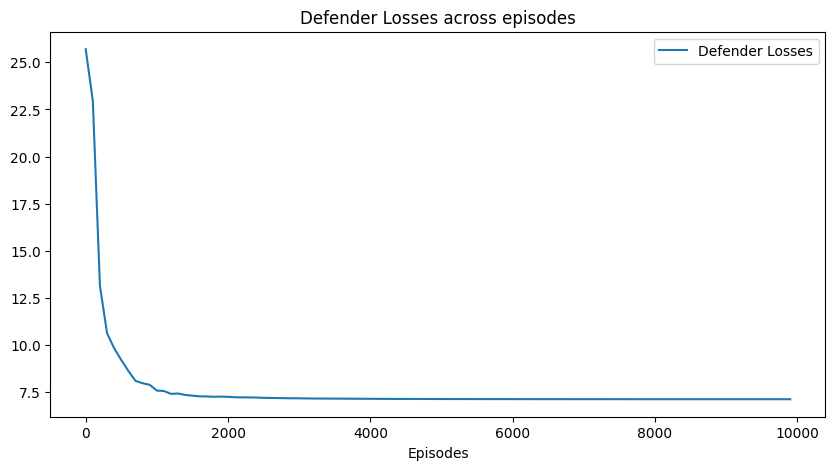

In [41]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(0,n_episodes,100),defender_losses, label='Defender Losses')
plt.legend()
plt.title("Defender Losses across episodes")
plt.xlabel("Episodes")

Text(0.5, 0, 'Episodes')

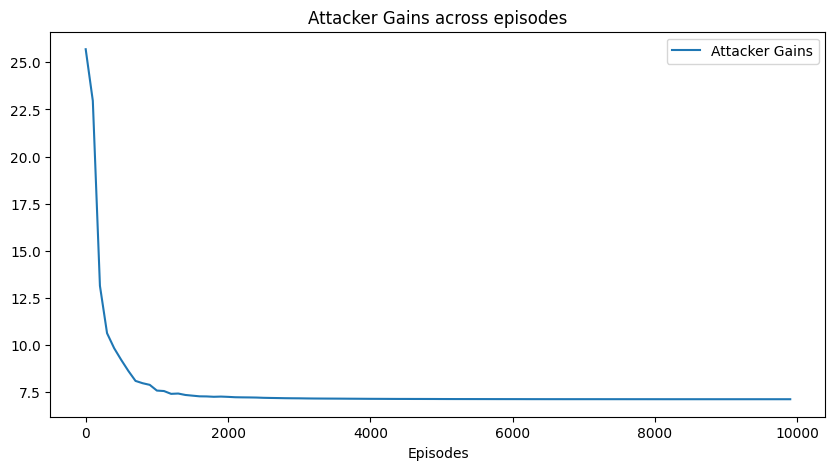

In [42]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(0,n_episodes,100),attacker_gains, label='Attacker Gains')
plt.legend()
plt.title("Attacker Gains across episodes")
plt.xlabel("Episodes")

(100, 5)


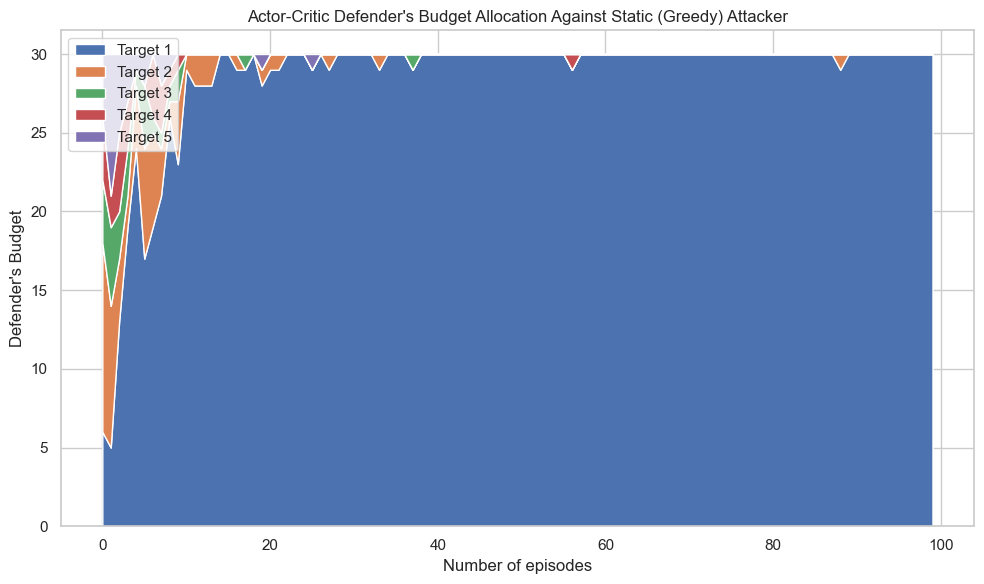

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose defender_allocations is a list of 1000 arrays, each len 5
# Convert it to a NumPy array
data = np.array(defender_allocations)  # shape = (1000, 5)

# Check shape
print(data.shape)  # should print (1000, 5)

# Create x-axis
x = np.arange(len(data))  # shape = (1000,)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Transpose so that each column (5 total) becomes one layer
# Plot stacked area chart
plt.stackplot(x, data.T, labels=[f'Target {i+1}' for i in range(data.shape[1])])

# Add legend and labels
plt.legend(loc='upper left')
plt.title("Actor-Critic Defender's Budget Allocation Against Static (Greedy) Attacker")
plt.xlabel("Number of episodes")
plt.ylabel("Defender's Budget")
plt.tight_layout()
plt.show()
